In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("car data.csv")

# Drop car name (not useful for prediction)
df = df.drop(['Car_Name'], axis=1)

# Create new feature: Age of car
df['Current_Year'] = 2026
df['Car_Age'] = df['Current_Year'] - df['Year']

df = df.drop(['Year', 'Current_Year'], axis=1)

# Convert categorical to numerical
df = pd.get_dummies(df, drop_first=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,0,1,0,1
1,4.75,9.54,43000,0,13,1,0,0,1
2,7.25,9.85,6900,0,9,0,1,0,1
3,2.85,4.15,5200,0,15,0,1,0,1
4,4.60,6.87,42450,0,12,1,0,0,1


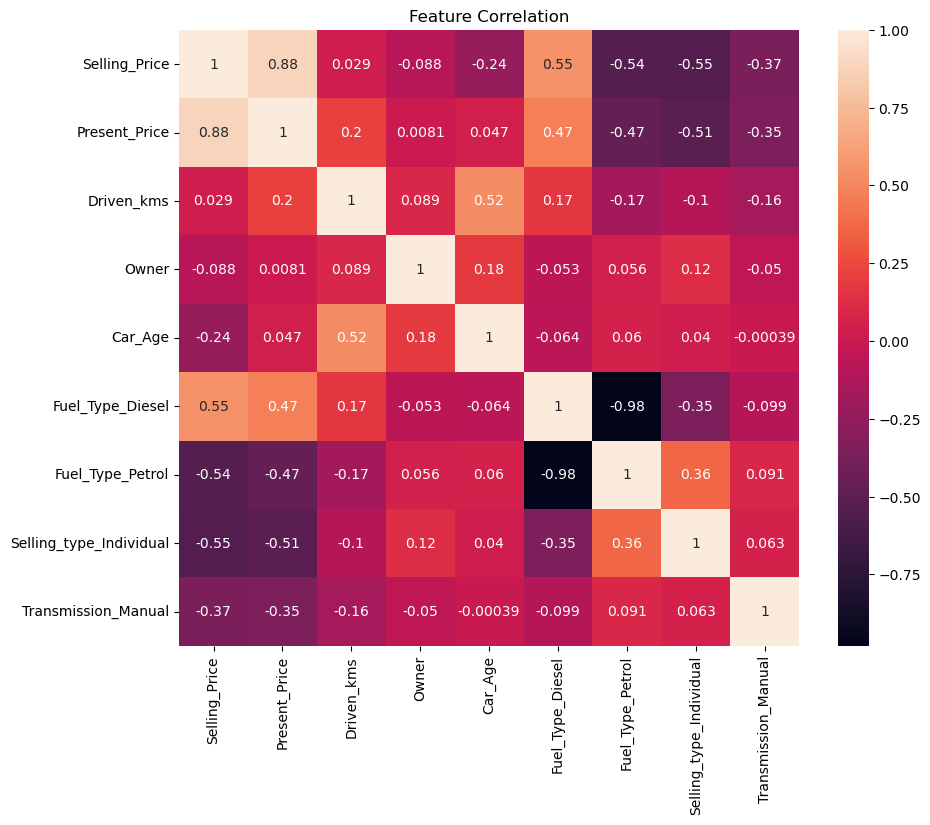

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.6563721311475414
MSE: 0.9783852778688525
R2 Score: 0.9575272215468607


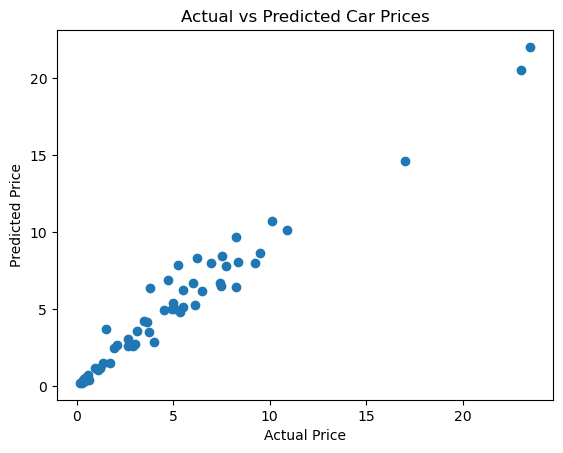

In [8]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()